# Lab 3: A Conditional Generative Model for Images
Welcome to lab 3! In the previous lab, we studied *unconditional* generation, for toy, two-dimensional data distributions. In this lab, we will study *conditional* generation on *images* from the MNIST dataset of handwritten digits. Each such MNIST image is not two dimensions but $32\times 32 = 1024$ dimensions! The nature of our new, more challenging setting will require us to take special care:
1. To tackle *conditional* generation, we will employ *classifier-free guidance* (CFG) (see Part 2.1).
2. To parameterize our learned vector field for high-dimensional image-valued data, a simple MLP will not suffice. Instead, we will adopt the *diffusion transformer* architecture (see part 3).

If you find any mistakes, or have any other feedback, please feel free to email us at `ezraerives@gmail.com`, `phold@mit.edu`, and `ronsh@mit.edu`. Enjoy!

In [19]:
import os
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math
import uuid
import random

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from einops.layers.torch import Rearrange

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")  

### Part 0: Recycling Components from Previous Labs
In this section, we'll re-import previous components from labs one and two. In doing so, we'll make some important updates. First, let's revisit our `Sampleable` class from labs one and two. Below, we have named it `OldSampleable`.

In [20]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
        """
        pass

As we will see shortly, a dataset like MNIST contains both images (in this case handwritten digits), as well as class labels (a value from 0-9 indicating). We will therefore generalize `Sampleable` to `LabeledSampleable` to accommodate these labels as well. Whereas the old, `Sampleable.sample` method returned only `samples: torch.Tensor`, `LabeledSampleable.sample` will return both **`samples: torch.Tensor` *and* `labels: Optional[torch.Tensor]`**. In this way, we are formally realizing every such `Sampleable` instance as sampling from a *joint distribution* over data and labels. We implement our new `LabeledSampleable` below.

In [21]:
class LabeledSampleable(ABC):
    """
    Distribution which can be sampled from
    """
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
            - labels: b
        """
        pass

For certain distributions, such as a Gaussian, it doesn't really make sense to think about labels. For this reason, we'll choose to implement our Gaussian class as a simple Sampleable. Note, again, that our "objectification" of a simple Gaussian is pedantic, and is done for pedagogical purposes as well as to emphasize distributions as first class objects within our mental model. In the wild, it is commen, and practical, to simple use e.g., the library function `torch.randn`/`torch.randn_like`.

$N(0, \sigma^2 I)$

For $p_{\text{simple}}$（流匹配的起点）

In [22]:
class IsotropicGaussian(nn.Module, Sampleable):
    """
    Sampleable wrapper around torch.randn
    """
    def __init__(self, shape: List[int], std: float = 1.0):
        """
        shape: shape of sampled data
        """
        super().__init__()
        self.shape = shape
        self.std = std
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples) -> torch.Tensor:
        return self.std * torch.randn(num_samples, *self.shape).to(self.dummy.device)

We'll also go ahead and implement a *Gaussian mixture* (GMM), as in the earlier labs, for which labels emerge naturally from the constituent mixture component. The GMM will allow us to sanity check our conditional training and inference implementations before we move on to images.

Label: 每个样本属于哪个 component  

GMM 模拟 MNIST 的数据+标签

10 类 = 10 component

In [23]:
class GMM(nn.Module, LabeledSampleable):
  def __init__(self, means: torch.Tensor, covariances: torch.Tensor, weights: torch.Tensor):
    super().__init__()
    self.means = nn.Buffer(means)
    self.covariances = nn.Buffer(covariances)
    self.weights = nn.Buffer(weights)

  def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Args:
      - num_samples: the desired number of samples
    Returns:
      - samples: b n
      - labels: b
    """
    # Choose the amount of each mode
    # Perform multinomial sampling on CPU to avoid device-side assert errors
    labels = torch.multinomial(self.weights.cpu(), num_samples=num_samples, replacement=True).to(self.means.device)

    # Sample from each mode
    samples = torch.zeros(num_samples, self.means.shape[1]).to(self.means.device)
    for idx in range(len(self.means)):
      samples[labels == idx] = torch.randn_like(samples[labels == idx]) * self.covariances[idx] + self.means[idx]

    return samples, labels

Next, we make two updates in adding `ConditionalProbabilityPath` (and `GaussianConditionalProbabilityPath`):
1. We adjust to handle the addition of labels to `LabeledSampleable`. Recall earlier that our called our conditioning variable `z` with $z \sim p_{\text{data}}(z)$. Now, we sample both `z`, as well as a label `y`, with $(z,y) \sim p_{\text{data}}(z,y)$.
2. We ensure that the logic is compatible with shapes of arbitrary size, denoting this as `b ...`. Depending on the situation, this could refer to `b d` (one feature per batch element), or `b c h w` (batch, channels, height, width), when working with images.

In [24]:
class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_simple: Sampleable, p_data: LabeledSampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: b
        Returns:
            - x: samples from p_t(x), b ... (i.e.,. `b d`, `b c h w`, etc.)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples) # (b ...)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (b ...)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        pass

    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable b ...
            - t: time b
        Returns:
            - x: samples from p_t(x|z), b ...
        """
        pass

    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field b c h w
        """
        pass

    @abstractmethod
    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - score: b ...
        """
        pass

Finally, we add back in `GaussianConditionalProbabilityPath`, along with `LinearAlpha` and `LinearBeta`, defined similarly to the previous lab.

In [25]:
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,)), torch.zeros(1,)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,)), torch.ones(1,)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt a_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1)), torch.ones(1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1)), torch.zeros(1)
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: b
        Returns:
            - d/dt beta_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)

class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """

    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        return t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t b
        """
        return torch.ones_like(t)

class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        return 1-t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t: b
        """
        return - torch.ones_like(t)

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple_shape: List[int], alpha: Alpha, beta: Beta):
        p_simple = IsotropicGaussian(shape = p_simple_shape, std = 1.0)
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
        self.rearrange_scalar = Rearrange(f'b -> b{" 1" * len(p_simple_shape)}')

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        return self.p_data.sample(num_samples)

    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: b ...
            - t: b
        Returns:
            - x: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # (b 1 1 1)
        beta_t = self.rearrange_scalar(self.beta(t)) # (b 1 1 1)
        return alpha_t * z + beta_t * torch.randn_like(z)

    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b c h w
            - z: b c h w
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """
        alpha_t = self.rearrange_scalar(self.alpha(t)) # b
        beta_t = self.rearrange_scalar(self.beta(t)) # b
        dt_alpha_t = self.rearrange_scalar(self.alpha.dt(t)) # b
        dt_beta_t = self.rearrange_scalar(self.beta.dt(t)) # b

        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_score: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))
        beta_t = self.rearrange_scalar(self.beta(t))
        return (z * alpha_t - x) / beta_t ** 2

Now, let us accordingly update our `ODE`, `SDE`, and `Simulator` classes. This is pretty much a matter of
1. Updating `xt: b d` to `b ...`.
2. Adding support for an optional *conditioning* input `y: Optional[torch.Tensor]`. We will opt to more simply add a generic `**kwargs` to the signatures of the relevant methods (`drift_coefficient`, `diffusion_coefficient`, `step`, `simulate`, etc.).

In [26]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - drift_coefficient: b ...
        """
        pass

class SDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - drift_coefficient: b ...
        """
        pass

    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - diffusion_coefficient: b ...
        """
        pass

In [27]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: b ...
            - t: b
            - dt: b
        Returns:
            - nxt: b ...
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: b ...
            - ts: b
        Returns:
            - x_final: b ...
        """
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: b ...
            - ts: b nt
        Returns:
            - x_traj: b nt ...
        """
        x_traj = [x.clone()]
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            x_traj.append(x.clone())
        return torch.stack(x_traj, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        h = h.view([-1] + [1] * (len(xt.shape) - 1))
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

class EulerMaruyamaSimulator(Simulator):
    def __init__(self, sde: SDE):
        self.sde = sde

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        h = h.view([-1] + [1] * (len(xt.shape) - 1))
        return xt + self.sde.drift_coefficient(xt, t, **kwargs) * h + self.sde.diffusion_coefficient(xt, t, **kwargs) * torch.sqrt(h) * torch.randn_like(xt)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

Finally, let's add back in our definition of `Trainer`.

In [28]:
MiB = 1024 ** 2

def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size


class Trainer(ABC):
    def __init__(
        self,
        **kwargs
      ):
        super().__init__()
        self.model = None
        self.opt = None
        self.output_dir = None

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def checkpoint(self, step: int):
      pass

    def get_optimizer(self, lr: float):
        return torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

    def random_name(self) -> str:
        adjectives = ["autumn", "hidden", "bitter", "misty", "silent", "empty", "dry", "dark", "summer", "icy", "delicate", "quiet", "white", "cool", "spring", "winter", "patient"]
        foods = ["apple", "banana", "pear", "plum", "orange", "persimmon", "tangerine", "durian", "jackfruit", "jicama", "cantaloupe", "watermelon", "peach"]
        return f"{random.choice(adjectives)}-{random.choice(foods)}-{str(uuid.uuid4())[:8]}"

    def train(
        self,
        model: nn.Module,
        num_steps: int,
        lr: float = 1e-3,
        warmup_steps: int = 500,
        ckpt_every: Optional[int] = 500,
        run_name: Optional[str] = None,
        **kwargs
    ) -> Tuple[List[float], List[int]]:
        """
        Linear warmup from 0 -> lr over `warmup_steps`, then constant lr.
        """
        # Initialize run name and output directory
        run_name = run_name or self.random_name()
        self.output_dir = os.path.join("runs", run_name)
        os.makedirs(self.output_dir, exist_ok=False)
        print("Initialized output directory at: " + self.output_dir)

        # Grab size
        self.model = model
        size_b = model_size_b(self.model)
        print(f"Training model with size: {size_b / MiB:.3f} MiB")

        # Initialize optimizer and LR
        self.opt = self.get_optimizer(lr)
        self.model.train()

        for pg in self.opt.param_groups:
            pg["lr"] = 0.0

        # Main training loop
        losses: List[float] = []
        steps: List[int] = []

        pbar = tqdm(range(num_steps))
        for step in pbar:
            # Update LR
            if warmup_steps > 0 and step < warmup_steps:
                cur_lr = lr * float(step + 1) / float(warmup_steps)
            else:
                cur_lr = lr
            for pg in self.opt.param_groups:
                pg["lr"] = cur_lr

            # Forward + backward
            self.opt.zero_grad(set_to_none=True)
            loss = self.get_train_loss(**kwargs)
            loss.backward()

            # Take gradient step
            self.opt.step()

            losses.append(float(loss.detach().item()))
            steps.append(step)

            pbar.set_description(f"Step {step}, lr={cur_lr:.2e}, loss={loss.item():.4f}")

            # Callback if specified
            if ckpt_every is not None and step % ckpt_every == 0 and step > 0:
              self.model.eval()
              self.checkpoint(step)
              self.model.train()

        self.model.eval()
        return losses, list(range(num_steps))

# Part 1: Getting a Feel for MNIST
In this section, we'll get a feel for MNIST. We'll then experiment with adding noise to MNIST with `ConditionalGaussianProbabilityPath`.

In [29]:
class MNISTSampler(nn.Module, LabeledSampleable):
    """
    Sampleable wrapper for the MNIST dataset
    """
    def __init__(self):
        super().__init__()
        self.dataset = datasets.MNIST(
            root='./data',
            train=True,
            download=True,
            transform=transforms.Compose([
                transforms.Resize((32, 32)),
                transforms.ToTensor(),
                transforms.Normalize((0.1305,), (0.2891,)),
            ])
        )
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, c, h, w)
            - labels: shape (batch_size, label_dim)
        """
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")

        indices = torch.randperm(len(self.dataset))[:num_samples]
        samples, labels = zip(*[self.dataset[i] for i in indices])
        samples = torch.stack(samples).to(self.dummy)
        labels = torch.tensor(labels, dtype=torch.int64).to(self.dummy.device)
        return samples, labels

GMM 是低维 2D Gaussian 合成数据，接口（继承）与 MNISTSampler 一致。  
GMM 用 component index 模拟标签，MNISTSampler 用真实数字做标签。

Now let's view some samples under the conditional probability path.

直接插值 $x_t = t \cdot z + (1-t) \cdot \text{noise}$

mps


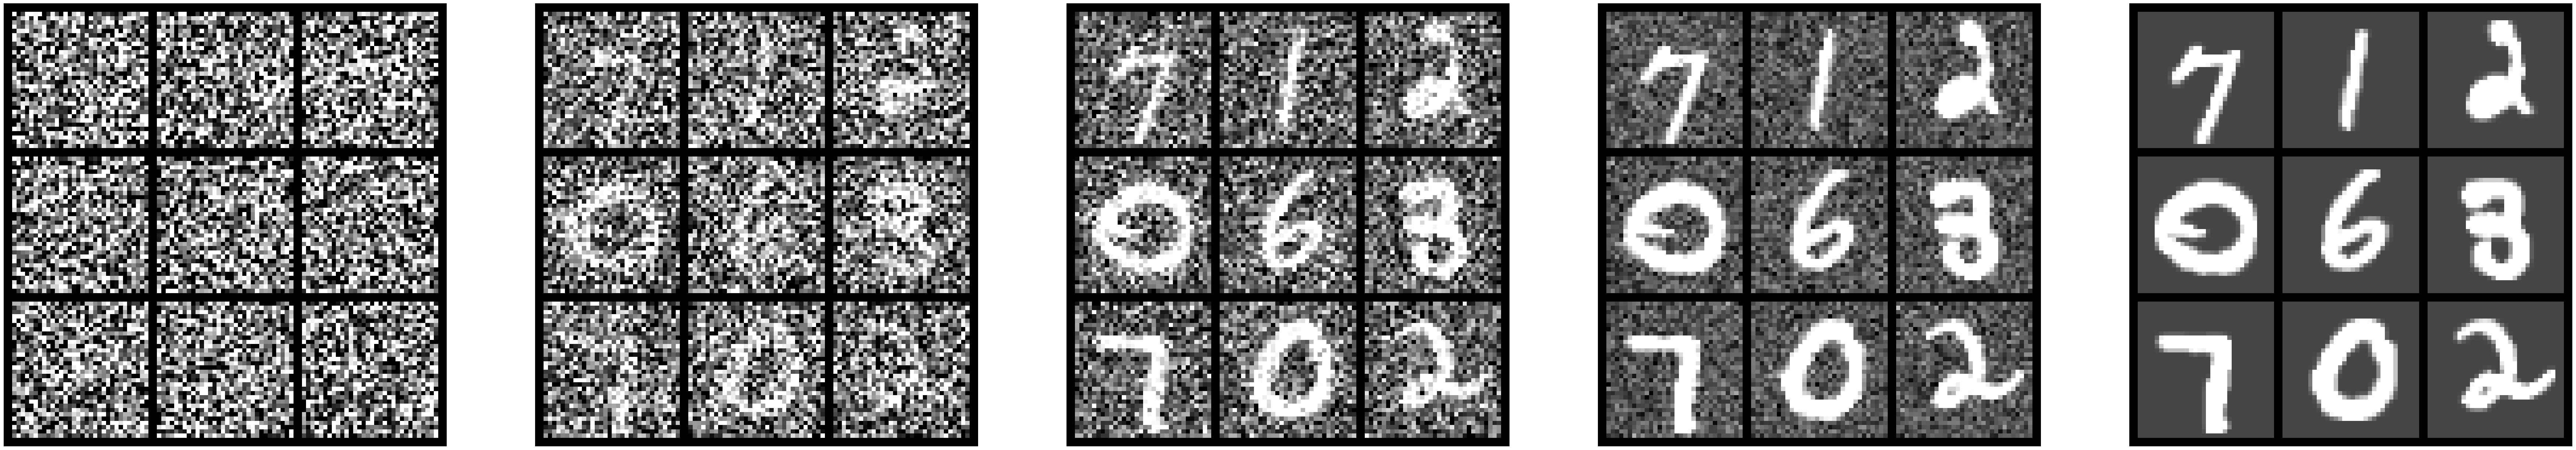

In [36]:
# Change these!
num_rows = 3
num_cols = 3
num_timesteps = 5

torch.backends.mps.is_available()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")  
print(device)

# Initialize our sampler
sampler = MNISTSampler().to(device)

# Initialize probability path
path = GaussianConditionalProbabilityPath(
    p_data = MNISTSampler(),
    p_simple_shape = [1, 32, 32],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)

# Sample
num_samples = num_rows * num_cols
z, _ = path.p_data.sample(num_samples)
z = z.view(-1, 1, 32, 32)

# Setup plot
fig, axes = plt.subplots(1, num_timesteps, figsize=(6 * num_cols * num_timesteps, 6 * num_rows))

# Sample from conditional probability paths and graph
ts = torch.linspace(0, 1, num_timesteps).to(device)
for tidx, t in enumerate(ts):
    tt = t.expand(num_samples) # b
    xt = path.sample_conditional_path(z, tt) # b 1 32 32
    grid = make_grid(xt, nrow=num_cols, normalize=True, value_range=(-1,1))
    axes[tidx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[tidx].axis("off")
plt.show()

# Part 2: Classifier Free Guidance

**Guidance**: Whereas for unconditional generation, we simply wanted to generate *any* digit, we would now like to be able to specify, or *condition*, on the identity of the digit we would like to generate. That is, we would like to be able to say "generate an image of the digit 8", rather than just "generate an image of a digit". We will henceforth refer to the digit we would like to generate as $x \in \mathbb{R}^{1 \times 32 \times 32}$, and the conditioning variable (in this case, a label), as $y \in \{0, 1, \dots, 9\}$. If we imagine fixing our choice of $y$, and take our data distribution as $p_{\text{simple}}(x|y)$, then we have recovered the unconditional generative problem, and we can construct a generative model using e.g., a conditional flow matching objective via $$\begin{align*}\mathcal{L}_{\text{CFM}}^{\text{guided}}(\theta;y) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\ \square &= z \sim p_{\text{data}}(z|y), x \sim p_t(x|z)\end{align*}$$
We may now then allow $y$ to vary by simply taking our conditional flow matching expectation to be over $y$ as well (rather than fixing $y$), and explicitly conditioning our learned approximation on $u_t^{\theta}(x|y)$ on the choice of $y$. We therefore obtain the the *guided* conditional flow matching objective $$\begin{align*}\mathcal{L}_{\text{CFM}}(\theta) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\ \square &= z,y \sim p_{\text{data}}(z,y), x \sim p_t(x|z)\end{align*}$$
Note that $(z,y) \sim p_{\text{simple}}(z,y)$ is obtained in practice by sampling an image $z$, and a label $y$, from our labelled (MNIST) dataset. This is all well and good, and we emphasize that if our goal was simply to sample from $p_{\text{data}}(x|y)$, our job would be done (at least in theory). In practice, one might argue that we care more about the *perceptual quality* of our images. To this end, we will a derive a procedure known as *classifier-free guidance*.

条件生成模型学到的 $\nabla \log p_t(y|x)$ 不够准，$u_t(x|y) = u_t(x) + b_t \nabla \log p_t(y|x)$.  
这里的 $\nabla \log p_t(y|x)$ 是模型隐式学出来的"分类器"——它在噪声中间状态 $x_t$ 上做判断（"这个模糊团块是 8 吗？"），而不是在干净图像上。

$$\tilde{u}t = \underbrace{(1-w) u_t(x|\varnothing)}_{\text{负权重，偏离"平均数字"}} + \underbrace{w u_t(x|y)}_{\text{加大力度推向 y}}
$$ 

- $w=1$ 时完全信任这个不太准的分类器，结果就是图像糊、类别边界模糊。
- $w>1$ 时分布变尖，多样性下降但清晰度上升。向量场更"确定"地推向你指定的那个数字   
  比如减去 $u_t(x|\varnothing)$ 等于说"别停在任何看起来像数字的地方，去只有 确定数字 才会去的地方" → 推到最典型、最不容置疑的区域

**Classifier-Free Guidance**: For the sake of intuition, we will develop guidance through the lense of Gaussian probability paths, although the final result might reasonably be applied to any probability path. Recall from the lecture that for $(a_t, b_t) = \left(\frac{\dot{\alpha}_t}{\alpha_t}, -\frac{\dot{\beta}_t \beta_t \alpha_t - \dot{\alpha}_t \beta_t^2}{\alpha_t}\right)$, we have $$u_t(x|y) = a_tx + b_t\nabla \log p_t(x|y).$$

向量场 = 收缩项（$a_t x$）+ 概率梯度项（$b_t \nabla \log p_t$）

  - $\nabla \log p_t(x)$：无条件 score——"哪里是高概率区域"，不管什么标签
  - $\nabla \log p_t(y|x)$：分类器梯度——"这个地方（$x$ 在噪声状态）看起来更像 y 吗"


This identity allows us to relate the *conditional marginal velocity* $u_t(x|y)$ to the *conditional score* $\nabla \log p_t(x|y)$. However, notice that $$\nabla \log p_t(x|y) = \nabla \log \left(\frac{p_t(x)p_t(y|x)}{p_t(y)}\right) = \nabla \log p_t(x) + \nabla \log p_t(y|x),$$


so that we may rewrite $$u_t(x|y) = a_tx + b_t(\nabla \log p_t(x) + \nabla \log p_t(y|x)) = u_t(x) + b_t \nabla \log p_t(y|x).$$
An approximation of the term $\nabla \log p_t(y|x)$ could be considered as a sort of noisy classifier (and in fact this is the origin of *classifier guidance*, which we do not consider here). In practice, people have noticed that the conditioning seems to work better when we scale the contribution of this classifier term, yielding
$$\tilde{u}_t(x|y) = u_t(x) + w b_t \nabla \log p_t(y|x)$$
where $w > 1$ is known as the *guidance scale*. We may then plug in $b_t\log p_t(y|x) = u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x)$ to obtain $$\begin{align}\tilde{u}_t(x|y) &= u_t(x) + w b_t \nabla \log p_t(y|x)\\
&= u_t(x) + w (u^{\text{target}}_t(x|y) - u^{\text{target}}_t(x))\\
&= (1-w) u_t(x) + w u_t(x|y). \end{align}$$
The idea is thus to train both $u_t(x)$ as well as the conditional model $u_t(x|y)$, and then combine them *at inference time* to obtain $\tilde{u}_t(x|y)$. Our recipe will thus be:
1. Train $u_t^{\theta} \approx u_t(x)$ as well as the conditional model $u_t^{\theta}(x|y) \approx u_t(x|y)$ using conditional flow matching.
2. At inference time, sample using $\tilde{u}_t^{\theta}(x|y)$.

"But wait!", you say, "why must we train two models?". Indeed, we can instead treat $u_t(x)$ as $u_t(x|y)$, where $y=\varnothing$ denotes *the absence of conditioning*. We may thus augment our label set with a new, additional $\varnothing$ label, so that $y \in \{0,1,\dots, 9, \varnothing\}$. This technique is known as **classifier-free guidance** (CFG). We thus arrive at
$$\boxed{\tilde{u}_t(x|y) = (1-w) u_t(x|\varnothing) + w u_t(x|y)}.$$

**Training and CFG**: We must now amend our conditional flow matching objective to account for the possibility of $y = \varnothing$. Of course, when we sample $(z,y)$ from MNIST, we will never obtain $y = \varnothing$, so we must introduce the possibliity of this artificially. To do so, we will define some hyperparameter $\eta$ to be the *probability* that we discard the original label $y$, and replace it with $\varnothing$. In practice, we might set $\varnothing = 10$, for example, as it is sufficient to distinguish it from the other digit identities. When we go and implement our model, we need ony be able to index into some embedding, such as via `torch.nn.Embedding`. We thus arrive at our CFG conditional flow matching training objective:
$$\begin{align*}\mathcal{L}_{\text{CFM}}(\theta) &= \,\,\mathbb{E}_{\square} \lVert u_t^{\theta}(x|y) - u_t^{\text{ref}}(x|z)\rVert^2\\
\square &= z,y \sim p_{\text{data}}(z,y), x \sim p_t(x|z),\,\text{replace $y$ with $\varnothing$ with probability $\eta$}\end{align*}$$
In plain English, this objective reads:
1. Sample an image $z$ and a label $y$ from $p_{\text{data}}$ (here, MNIST).
2. With probability $\eta$, replace the label $y$ with the null label $\varnothing \triangleq 10$.
3. Sample $t$ from $\mathcal{U}[0,1]$.
4. Sample $x$ from the conditional probability path $p_t(x|z)$.
5. Regress $u_t^{\theta}(x|y)$ against $u_t^{\text{ref}}(x|z)$.


### Question 2.2: Training for Classifier-Free Guidance
In this section, you'll the training objective $\mathcal{L}_{\text{CFM}}(\theta)$ in which $u_t^{\theta}(x|y)$ is an instance of the class `ConditionalVectorField` described below.

In [31]:
class ConditionalVectorField(nn.Module, ABC):
    """
    Conditional vector field u_t^theta(x|y)
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        Returns:
        - u_t^theta(x|y): b ...
        """
        pass

class CFGVectorFieldODE(ODE):
    def __init__(self, net: ConditionalVectorField, null_label: int, guidance_scale: float = 1.0):
        self.net = net
        self.guidance_scale = guidance_scale
        self.null_label = null_label

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        """
        guided_vector_field = self.net(x, t, y)
        unguided_y = torch.ones_like(y) * self.null_label
        unguided_vector_field = self.net(x, t, unguided_y)
        return (1 - self.guidance_scale) * unguided_vector_field + self.guidance_scale * guided_vector_field


Trainer   
    ↓  
CFGTrainer  ← train with classifier-free guidance     
    ↓  
MNISTCFGTrainer  

**Your job**: Fill in `CFGFlowTrainer.get_train_loss`, so that it implements $\mathcal{L}_{\text{CFM}}(\theta)$ described above. In doing so, feel free to "hardcode" $\varnothing = 10$. A more general implementation would not make this MNIST-specific assumption, but for the sake of this assignment you may do so. We recommend completing Question 2.2 and Question 2.3 together, as their combination can be tested in Sanity Check 2.4.

**Hints**:
1. To sample an image $(z,y) \sim p_{\text{data}}$, use `self.path.p_data.sample`
2. You can generate a mask corresponding to "probability $\eta$" via `mask = torch.rand(batch_size) < self.eta`.
3. You can sample $t \sim \mathcal{U}[0,1]$ using `torch.rand(batch_size, 1, 1, 1)`. Don't mix up `torch.rand` with `torch.randn`!    
    - `torch.rand` 均匀分布 $\mathcal{U}(0,1)$
    - `torch.randn`：标准正态 $\mathcal{N}(0,1)$   
4. You can sample $x \sim p_t(x|z)$ using `self.path.sample_conditional_path`.

In [37]:
class CFGTrainer(Trainer):
    def __init__(self, path: GaussianConditionalProbabilityPath, eta: float, null_label: int, eps: float = 0.001, **kwargs):
        assert eta > 0 and eta < 1
        super().__init__(**kwargs)
        self.eta = eta
        self.eps = eps
        self.path = path
        self.null_label = null_label

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z,y from p_data
        z, y = self.path.p_data.sample(batch_size) # (b, c, h, w) (b, label_dim)

        # Step 2: Set each label to 10 (i.e., null) with probability eta
        mask = torch.rand(batch_size) < self.eta
        y[mask] = self.null_label

        # Step 3: Sample t and x
        t = torch.rand(batch_size, device=z.device)
        x = self.path.sample_conditional_path(z, t)
        
        # Step 4: Regress and output loss
        return torch.nn.functional.mse_loss(self.model(x, t, y), self.path.conditional_vector_field(x, z, t)) 

To sanity check our implementation of `CFGTrainer`, we'll train a simple MLP-based model to sample conditionally from a Gaussian mixture. First, let's implement the class `MLPConditionalVectorField`.

ConditionalVectorField    
    ├── MLPConditionalVectorField   
    └── DiffusionTransformerFlowModel  

### Question 2.3: MLPConditionalVectorField
**Your job:** Implement `MLPConditionalVectorField.forward`.

In [38]:
# Sanity check: implement MLPConditionalVectorField

class MLP(nn.Module):
  def __init__(self, dims: List[int], activation: Type[torch.nn.Module] = torch.nn.SiLU, final_init: bool = False):
    super().__init__()
    mlp = []
    for idx in range(len(dims) - 1):
        mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
        if idx < len(dims) - 2:
            mlp.append(activation())
    self.net = torch.nn.Sequential(*mlp)

    if final_init:
      nn.init.zeros_(self.net[-1].weight)
      nn.init.zeros_(self.net[-1].bias)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d
    """
    return self.net(x)

class MLPConditionalVectorField(ConditionalVectorField):
  def __init__(
      self,
      dim: int,
      hidden_dim: int,
      class_dim: int,
      num_classes: int
    ):
    super().__init__()
    self.mlp = MLP([dim + class_dim + 1, hidden_dim, hidden_dim, dim]) # dims for each layer
    self.class_embedding = nn.Embedding(num_classes + 1, class_dim)

    """
    Class embedding lookup table: takes an input label y (0-10)
    and returns a vector of dimension `class_dim`.
    
    MLP
    Input: pixel-space state x, label embedding embed(y), and time t
           [x (dim), embed y (class_dim), t (1)]
    Output: vector field u_t^θ(x | y) with the same dimensionality as x   
    The MLP learns a vector field that, given the current state x,
    target label y, and time t, predicts the direction (velocity)
    for the particle's next step.
    
    [dim+class_dim+1] → [hidden_dim] → [hidden_dim] → [dim]
    """
    
  def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
      """
      Args:
      - x: b d
      - t: b
      - y: b
      Returns:
      - u_t^theta(x|y): (b, c, h, w)
      """
      embed_y = self.class_embedding(y) # (b, class_dim)
      t = t.unsqueeze(-1)  # (b,) → (b, 1)
      mlp_in = torch.cat([x, embed_y, t], dim=-1)
      return self.mlp(mlp_in)

### Sanity Check 2.4
Finally, let's check our work in Questions 2.2 and 2.3 by combining `CFGTrainer`, `CFGVectorFieldODE`, and `MLPConditionalVectorField` to sample from a Gaussian mixture (`GMM`) instance.



GMM toy demo

True
Initialized output directory at: runs/autumn-pear-3805b6eb
Training model with size: 0.259 MiB


Step 2999, lr=1.00e-03, loss=0.8646: 100%|██████████| 3000/3000 [00:28<00:00, 105.27it/s]


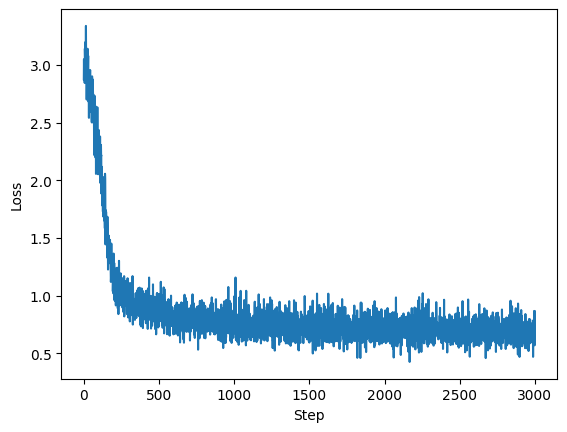

In [39]:
#######################################################################
# Train MLP-based Conditional Vector Field to target Gaussian mixture #
#######################################################################
print(torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") 

# Initialize GMM
angles = [0, 2 * math.pi / 3, 4 * math.pi / 3]
means = 2 * torch.tensor([[math.cos(a), math.sin(a)] for a in angles])
covs = torch.tensor([0.2, 0.2, 0.2])
weights = torch.tensor([1/3, 1/3, 1/3])
gmm = GMM(means, covs, weights).to(device)

# Initialize probability path
path = GaussianConditionalProbabilityPath(
    p_data = gmm,
    p_simple_shape = [2],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)
vector_field = MLPConditionalVectorField(
    dim = 2,
    hidden_dim = 256,
    class_dim = 2,
    num_classes = 3
).to(device)

# Train vector field
trainer = CFGTrainer(
    path=path,
    eta=0.25,
    null_label=3,
)
losses, steps = trainer.train(model=vector_field, num_steps=3000, lr=1e-3, batch_size=250)
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

100%|██████████| 99/99 [00:00<00:00, 1872.94it/s]


Text(0.5, 1.0, 'Unguided Samples')

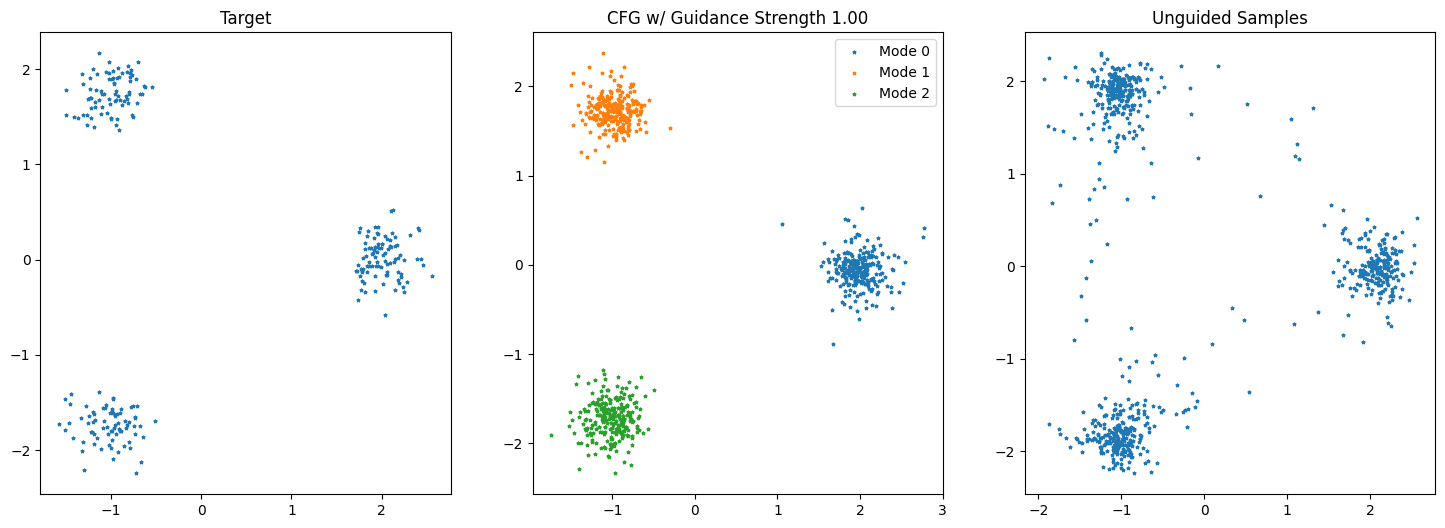

In [40]:
#####################
# Visualize Results #
#####################

# User knobs
guidance_strength = 1.0 # try changing me!

fig, axes = plt.subplots(1, 3, figsize=(6 * 3, 6))

# Panel 1: Target
ax = axes[0]
x_data, _ = gmm.sample(250)
x_data = x_data.detach().cpu().numpy()
ax.scatter(x_data[:, 0], x_data[:, 1], s=5, marker="*")
ax.set_title("Target")

# Panel 2: Conditioned on each mode
ax = axes[1]
cfg_vector_field = CFGVectorFieldODE(vector_field, guidance_scale=guidance_strength, null_label=3)
simulator = EulerSimulator(cfg_vector_field)

batch_size = 250
labels = torch.arange(3).repeat_interleave(batch_size).to(device)
x_init = path.p_simple.sample(3 * batch_size) # b 2
ts = torch.linspace(0, 1, 100).expand(3 * batch_size, -1).to(device) # b nt
xs = simulator.simulate(x_init, ts, y=labels) # b 2
for idx in range(3):
    xs_idx = xs[idx * batch_size: (idx + 1) * batch_size].detach().cpu().numpy()
    ax.scatter(xs_idx[:, 0], xs_idx[:, 1], s=5, label=f"Mode {idx}", marker="*")
ax.legend()
ax.set_title(f"CFG w/ Guidance Strength {guidance_strength:.2f}")

# Panel 3: Unconditioned
ax = axes[2]
batch_size = 750
labels = torch.ones(batch_size).long().to(device) * 3
x_init = path.p_simple.sample(batch_size) # b 2
ts = torch.linspace(0, 1, 100).expand(batch_size, -1).to(device) # b nt
xs = simulator.simulate(x_init, ts, y=labels).detach().cpu().numpy() # b 2
ax.scatter(xs[:, 0], xs[:, 1], s=5, label=f"Mode {idx}", marker="*")
ax.set_title(f"Unguided Samples")

# Part 3: Building a Diffusion Transformer
At this point, we have discussed classifier free guidance, and the necessary considerations that must be made on the part of our model and in training our model. What remains is to actually discuss the choice of model. In particular, our usual choice of an MLP, while fine for the simple distributions of the previous lab, will no longer suffice. To this end, we will implement a **diffusion transformer** component-by-component!

MLP 本身没有空间结构知觉，相邻像素和远距离像素同等对待；计算量大。  
Transformer 通过 **Self Attention** 让每个像素块能看全局，同时通过 **patch 化** 压缩计算量。


```mermaid
flowchart LR

    A["b × 1 × 32 × 32"]
    
    subgraph P["Patchification"]
        B["Patchifier"]
        C["b × n × d"]
    end

    subgraph T["Transformer"]
        D["Diffusion Transformer"]
        E["t_embed + y_embed"]
    end

    subgraph R["Reconstruction"]
        G["Depatchifier"]
        H["b × 1 × 32 × 32"]
    end

    A --> B --> C --> D --> G --> H
    E --> D

    N1["Note:<br/>Each image is split into p×p patches<br/><br/>Number of tokens:<br/> n = (32/p)^2"]

    B -.-> N1

    classDef input fill:#4C78A8,stroke:#2F4B7C,color:white,fill-opacity:0.2;
    classDef patch fill:#F58518,stroke:#B35900,color:white,fill-opacity:0.2;
    classDef trans fill:#54A24B,stroke:#2F6B2F,color:white,fill-opacity:0.2;
    classDef recon fill:#E45756,stroke:#8C2B2B,color:white,fill-opacity:0.2;

    class A input;
    class B,C patch;
    class D,E trans;
    class G,H recon;
```

- 每个 token 对应图像的一个 8×8 区域，经过卷积后变成一个 $d$ 维向量;   
  把图像当作文本序列，每个 patch 是一个"词"
- FourierEncoder 将标量 t 映射到高维正弦余弦特征 
  因为 t ∈ [0,1] 是标量，模型不好感知  
  高维映射给时间加"指纹"，让模型分辨 t=0.1 和 t=0.9 并且学“时间的频率分解方式” 对于流匹配，$t$ 接近 1 时向量场变化剧烈（插值到精确图像），可能需要不同的频率分辨率。
- Patchifier 用卷积层把 1×32×32 图像映射为 $d × (h/p) × (w/p)$ ("展平 patch + 线性投影")
- DiffusionTransformerLayer

### Question 3.1: Fourier Time Encoder

First, we implement a *Fourier time encoder*, which maps a scalar time value $t \in [0,1]$ to
$$
    t^{\text{emb}} = \begin{bmatrix}
    \cos(2\pi w_1 t) & \cdots & \cos(2\pi w_d t) & \sin(2\pi w_1 t) & \cdots & \sin(2\pi w_d t)
    \end{bmatrix}^T,
$$
where the weights $w_i \sim \mathcal{N}(0, 1)$ are drawn from a unit normal.

**Your job**: Implement `FourierEncoder`.

In [41]:
class FourierEncoder(nn.Module):
    """
    Based on https://github.com/lucidrains/denoising-diffusion-pytorch/blob/main/denoising_diffusion_pytorch/karras_unet.py#L183
    """
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: b
        Returns:
        - embeddings: b d
        """
        # Step 1: compute frequencies f_i = 2 * pi * w_i * t
        f_i = 2 * torch.pi *  self.weights * t.unsqueeze(-1) # (b, 1) * (1, half_dim) → (b, half_dim)

        # Step 2: compute sin(f_i) and cos(f_i)
        sin_fi = torch.sin(f_i)
        cos_fi = torch.cos(f_i)

        # Step 3: Concatenate and return
        return torch.cat([cos_fi, sin_fi], dim=-1)

### Question 3.2: Patchifier

The patchifier takes in an image-valued tensor of shape `b c 32 32`, and *patchifies* it to shape `b (h / p * w / p) d`, where `d` denotes the diffusion transformer hidden dimension (`dim` in the implementation below), `p` denotes the patch size, and `h` and `w` denote the image height and width, respectively. It does this in two steps:
1. Applies a convolutional layer mapping the an input of shape `b c 32 32` to `b d h/p h/w`.
2. Rearranges from `b d h/p h/w` to `b (h/p h/w) d` (i.e., `n = h/p * h/w` tokens with dimension `d`).

Note that while `c=1` for the standard, pixel-space diffusion transformer we'll be training in this section, this will no longer be the case when training our latent diffusion transformer in Section 5.

**Your job:** Implement `Patchifier`.

In [42]:
class Patchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, c_in: int, dim: int):
    super().__init__()
    assert img_size % patch_size == 0, "Image size must be divisible by patch size"

    # (b, c_in, H, W) to (b, dim, H/p, W/p)
    self.conv = nn.Conv2d(c_in, dim, kernel_size=patch_size, stride=patch_size)
    
    # flatten (b, dim, H/p, W/p) to (b, (H/p, W/p), dim)
    self.rearrange = Rearrange('b d h w -> b (h w) d')

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: (bs, 1, img_size, img_size)
    Returns:
    - tokens: (b, n, dim), where n = (H/p)*(W/p)
    """
    x = self.conv(x)      # (b, 1, 32, 32) → (b, dim, 4, 4)
    tokens = self.rearrange(x) # (b, dim, 4, 4) → (b, 16, dim)
    return tokens


### Question 3.3: Diffusion Transformer
Our data is now in the shape `b n d`, where `n` denotes the number of image tokens per image. We'll now pass it through a transformer. In the spirit of banging your head against a wall, you'll be implementing the whole thing! In particular, implementing attention from scratch is an incredibly valuable exercise if you haven't done so already. As you work through this question, feel free to consult the diffusion transformer arcihtectural diagram above, taken from [1].


**Your job**: finish `MHA` (multi-headed self-attention), `DiffusionTransformerLayer`, and `DiffusionTransformer`.

**Recommended steps**: Let's work our way down.
1. First, implement `DiffusionTransformer`. In particular, we recommend learning fixed per-position encodings using e.g., `nn.Parameter(torch.randn(n_tokens, dim))`. Note that you have access to the (fixed) number of tokens via the argument `n_tokens`. Additionally, you'll need to initialize `depth` instances of `DiffusionTransformerLayer`. Then, a forward pass simply involves adding your positional encodings to your input (be careful about broadcasting!), and passing through the diffusion transformer layers.
2. Second, implement `DiffusionTransformerLayer`. For this we refer to the diagram above. Note that adaLN-Zero refers to zero-initializing the conditioning MLP weights (the last layer will suffice). While this is optional, zero-initializing these residual connections often helps to stablize training. We note that $\gamma, \beta, \alpha$ should have shape `b d` (be careful about broadcasting), and that the scale and shift operation is usually implemented as the modulation $x \mapsto x * (1 + \gamma) + \beta$. For the feed-forward network, feel free to use the previously defined `MLP` class. A typical choice in DiT's is to use hidden dimensions `[dim, 4 * dim, dim]`.
3. Finally, implemented multi-headed self-attention. For this, the internet is your friend :)

We highly recommend not using a ChatGPT, Gemini, Claude, or any other large language model to write this code for you. This lab is optional and you'd only be robbing yourself of a carefully curated opportunity to get your hands dirty and do some machine learning!

<img src="DiT.jpg" width="40%">

3. Finally, implemented multi-headed self-attention. For this, the internet is your friend :)

$$\text{Attention} = \text{softmax}\left(\frac{QK^T}{\sqrt{d_{head}}}\right)V
$$

投影矩阵不同，同一个 $x$，乘三个不同的权重矩阵 $W^Q$、$W^K$、$W^V$，得到三种不同的"角色"

In [88]:
class MHA(nn.Module):
  """
  Multi-headed self-attention 
  Softmax projects logits onto the probability simplex, producing a single attention distribution per head.
  Hence, multi-head attention can model multiple distinct distributions to capture different patterns.
  """
  def __init__(self, dim: int, heads: int):
    super().__init__()
    assert dim % heads == 0

    self.dim = dim
    self.heads = heads
    self.dim_head = self.dim // self.heads

    self.W_Q = nn.Linear(self.dim, self.dim)
    self.W_K = nn.Linear(self.dim, self.dim)
    self.W_V = nn.Linear(self.dim, self.dim)
    
    self.W_O = nn.Linear(self.dim, self.dim) 

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b n d
    """
    # Compute queries, keys, and values
    queries, keys, values = self.W_Q(x), self.W_K(x), self.W_V(x)  # (b, n, d)
    b, n, d = queries.shape[0], queries.shape[1], queries.shape[2]

    # Fold head into batch dimension
    # We would like to parallelize the computation and compuate on a super batch.
    queries = queries.reshape(b, n, self.heads, self.dim_head) # (b, n, head, d_head)
    queries = queries.transpose(1, 2) # (b, head, n, d_head)
    queries = queries.reshape(b * self.heads, n, self.dim_head) # (b * head, n, d_head)
    keys = keys.reshape(b, n, self.heads, self.dim_head).transpose(1, 2).reshape(b * self.heads, n, self.dim_head)
    values = values.reshape(b, n, self.heads, self.dim_head).transpose(1, 2).reshape(b * self.heads, n, self.dim_head)
    
    # Compute attention
    # Combine with values
    keys_T = keys.transpose(-2, -1)
    attention = torch.softmax(queries @ keys_T / self.dim_head ** 0.5, dim=-1) @ values

    # Unfold heads to (b, n, d)
    z = attention.reshape(b, self.heads, n, self.dim_head).transpose(1, 2).reshape(b, n, self.heads * self.dim_head)

    # Pass throuh FF and return
    return self.W_O(z)

2. Second, implement `DiffusionTransformerLayer`. For this we refer to the diagram above. Note that adaLN-Zero refers to zero-initializing the conditioning MLP weights (the last layer will suffice). While this is optional, zero-initializing these residual connections often helps to stablize training. We note that $\gamma, \beta, \alpha$ should have shape `b d` (be careful about broadcasting), and that the scale and shift operation is usually implemented as the modulation $x \mapsto x * (1 + \gamma) + \beta$. For the feed-forward network, feel free to use the previously defined `MLP` class. A typical choice in DiT's is to use hidden dimensions `[dim, 4 * dim, dim]`.

In [85]:
DEBUG_FLAG = False

class DiffusionTransformerLayer(nn.Module):
  def __init__(
      self,
      dim: int,
      heads: int,
  ):
    """
    Args:
    - dim: dimension of hidden layers
    - heads: number of attention heads
    """
    super().__init__()

    # Init normalization
    # LayerNorm normalizes each token’s features to zero mean and unit variance, stabilizing training.
    self.ln1 = nn.LayerNorm(dim, elementwise_affine=False)
    self.ln2 = nn.LayerNorm(dim, elementwise_affine=False)

    # Initialize conditioning to zero - stabilizes residual connection!
        
    # Then, adaLN replaces fixed scale/shift with condition-dependent scale/shift.
    # MLP maps conditioning signal $c$ (time + label) to $(\gamma, \beta, \alpha)$ that 
    # adaptively modulate the normalized features.
    # Zero-initialize adaLN output so gate=0 at init. The network starts as an identity function. 
    # Gradients still flow through the skip connection, and the model learns deviations from identity gradually, 
    # preventing the initial vector field from diverging.
    self.adaLN = MLP([dim, 4 * dim, 6 * dim], final_init=True)

    # Init attention
    self.mha = MHA(dim, heads)

    # Init feedforward
    self.ffn = MLP([dim, 4 * dim, dim])

  def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - c: b d
    Returns:
    - x: b n d
    """
    if DEBUG_FLAG:      
      print("x:", x.shape)
      print("c:", c.shape)
      print("ln1:", self.ln1.normalized_shape)
    
    # Compute conditioning gating, scaling, and bias
    adaLN_out = self.adaLN(c).unsqueeze(1) # (b, 1, 6*dim)
    adaLN_out = torch.chunk(adaLN_out, 6, dim=-1) # contiguous chunks keep nearby latent features together
    scale_gamma_1, shift_beta_1, scale_gate_1 = adaLN_out[0], adaLN_out[1], adaLN_out[2]
    scale_gamma_2, shift_beta_2, scale_gate_2 = adaLN_out[3], adaLN_out[4], adaLN_out[5]
        
    # Attention + residual connection
    x_norm1 = self.ln1(x)
    if DEBUG_FLAG:   
      print("x_norm1 shape: ", x_norm1.shape)
      print("affine parameter shape: ", scale_gamma_1.shape, shift_beta_1.shape)
    x_norm1 = x_norm1 * (1 + scale_gamma_1) + shift_beta_1
    x = x + scale_gate_1 * self.mha(x_norm1)

    # Feedforward + residual connection
    x_norm2 = self.ln2(x)
    x_norm2 = x_norm2 * (1 + scale_gamma_2) + shift_beta_2
    x = x + scale_gate_2 * self.ffn(x_norm2)
    return x

1. First, implement `DiffusionTransformer`. In particular, we recommend learning fixed per-position encodings using e.g., `nn.Parameter(torch.randn(n_tokens, dim))`. Note that you have access to the (fixed) number of tokens via the argument `n_tokens`. Additionally, you'll need to initialize `depth` instances of `DiffusionTransformerLayer`. Then, a forward pass simply involves adding your positional encodings to your input (be careful about broadcasting!), and passing through the diffusion transformer layers.

In [72]:
class DiffusionTransformer(nn.Module):
  def __init__(
      self,
      depth: int,
      n_tokens: int,
      dim: int,
      **layer_kwargs,
  ):
    """
    Args:
    - n_tokens: sequence length (for sake of positional embeddings)
    - dim: dimension of hidden layers
    - heads: number of attention heads
    - depth: number of layers
    """
    super().__init__()
    
    # Self-attention doesn’t know order or spatial layout, and tokens are just a set.
    # However, each token should carry both its content and where it is, 
    # which lets the model distinguish patterns based on position.
    self.pos_emb = nn.Parameter(torch.randn(n_tokens, dim)) # (n, dim) 
    
    # Each block uses self-attention and feedforward layers, 
    # conditioned on the time embedding.
    self.DiT_layers = nn.ModuleList([DiffusionTransformerLayer(dim, **layer_kwargs) for _ in range(depth)])

  def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    - c: b d
    Returns:
    - x: b n d
    """
    # Add positional encodings as a bias
    x = x + self.pos_emb.unsqueeze(0)
    for layer in self.DiT_layers:
      x = layer(x, c)
    return x


### Question 3.4 Depatchifier
After the diffusion transformer, we need to convert from `b n d` back to `b 1 h w`.

**Your job:** Implement `Depatchifier`.

**Hints**: One approach would be to
1. Start with some sort of normalization. `nn.LayerNorm` or `nn.RMSNorm` wil suffice.
2. Pass through some MLP to obtain `b (h/p w/p) (f p p)` (ie, map to dimension $d=fp^2$, for patch size $p$ and "final dimension" $f$.
3. Rearrange to `b f h w`.
4. Pass through final convolution to obtain output of shape `b 1 h w`.

In [61]:
class Depatchifier(nn.Module):
  def __init__(self, img_size: int, patch_size: int, dim: int, final_dim: int, c_out: int):
    super().__init__()
    self.patch_size = patch_size
    assert img_size % patch_size == 0, "Image size must be divisible by patch size"

    self.ln = nn.LayerNorm(dim, elementwise_affine=False)
    
    # (b, n, dim) as the token sequence without spatial structure
    # to inflate to be (b, n, f * p * p) as a patch of pixels.
    self.mlp = MLP([dim, 4 * dim, final_dim * patch_size * patch_size])
    
    # b (h/p w/p) (f p p) is b n dim
    h_tokens = img_size // patch_size
    self.rearrange = Rearrange('b (h w) (c p1 p2) -> b c (h p1) (w p2)', h=h_tokens, w=h_tokens, p1=patch_size, p2=patch_size) 
    self.final_conv = nn.Conv2d(in_channels=final_dim, out_channels=c_out, kernel_size=1)
    
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b n d
    Returns:
    - x: b 1 32 32
    """
    x = self.ln(x)
    x = self.mlp(x)
    x = self.rearrange(x)
    return self.final_conv(x)


### Question 3.5: Putting It All Together
Finally, let's implement our DiT-based guided flow model $u_t^\theta(x|y)$ with the class `DiffusionTransformerFlowModel`.

**Your job**: Implement `DiffusionTransformerFlowModel`.

**Hint**:
1. To embed the guiding input `y`, you'll need class labels. You can reuse your solution from `MLPConditionalVectorField`. In particular, we recommend using `nn.Embedding(num_classes=11, embedding_dim=dim)`. Note we use 11 - not 10 - classes to account for the presence of the null label.
2. Follow the DiT overview diagram: embed $t$ and $y$, add them together to obtain the guiding variable. Pass $x$ through the patchifier, and then pass the patchifier output and $t + y$ through the diffusion transformer. Finally, pass the DiT output through the depatchifier.

In [65]:
class DiffusionTransformerFlowModel(ConditionalVectorField):
  def __init__(
      self,
      img_size: int = 32,
      patch_size: int = 8,
      num_layers: int = 12,
      c: int = 1,
      dim: int = 256,
      heads: int = 4,
      final_dim: int = 10,
      n_classes: int = 11,
    ):
      super().__init__()
      # 0. Construct time_embedder and y_embedder
      self.time_embedder = FourierEncoder(dim=dim)
      self.y_embedder = nn.Embedding(num_embeddings=11, embedding_dim=dim)

      # 1. Construct patchifier
      self.patchifier = Patchifier(img_size, patch_size, c, dim)

      # 2. Construct DiT
      n_tokens = (img_size // patch_size) ** 2
      self.dit = DiffusionTransformer(depth=num_layers, n_tokens=n_tokens, dim=dim, heads=heads)

      # 3. Construct de-patchifier
      self.depatchifier = Depatchifier(img_size, patch_size, dim, final_dim, c_out=c)

  def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Args:
    - x: b 1 32 32
    - t: b 1 1 1
    - c: b 1 1 1
    Returns:
    - u_t^theta(x|y): b 1 32 32
    """
    # 1. Embed time and y
    embed_y = self.y_embedder(y.squeeze())    # (b, d)
    embed_t = self.time_embedder(t.squeeze()) # (b, d)
    c = torch.add(embed_y, embed_t)
    
    # 2. Patchify
    x = self.patchifier(x)
    
    # 3. Pass through DiT
    x = self.dit(x, c)

    # 4. Depatchify
    x = self.depatchifier(x)

    return x

### Training the Diffusion Transformer

In [53]:
##################
# Training utils #
##################

@torch.no_grad()
def visualize_output(model, path, samples_per_class: int = 10, num_timesteps: int = 100, guidance_scales: List[float] = [1.0, 3.0, 5.0], save_path: Optional[str] = None, use_tqdm: bool = True):
  # Graph
  fig, axes = plt.subplots(1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10))

  for idx, w in enumerate(guidance_scales):
      # Setup ode and simulator
      ode = CFGVectorFieldODE(model, guidance_scale=w, null_label=10)
      simulator = EulerSimulator(ode)

      # Sample initial conditions
      y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
      num_samples = y.shape[0]
      x0 = path.p_simple.sample(num_samples) # (num_samples, 1, 32, 32)

      # Simulate
      ts = torch.linspace(0,0.999,num_timesteps).view(1, -1, 1, 1, 1).expand(num_samples, -1, 1, 1, 1).to(device)
      x1 = simulator.simulate(x0, ts, y=y, use_tqdm=use_tqdm)

      # Plot
      v_min, v_max = x1.min(), x1.max()
      x1 = (x1 - v_min) / (v_max - v_min)
      grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(0,1))
      axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
      axes[idx].axis("off")
      axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)

  # Save
  if save_path is not None:
      plt.savefig(save_path)
      plt.close()
  else:
    plt.show()

class MNISTCFGTrainer(CFGTrainer):
  '''
  CFG Trainer with MNIST-specific callback
  '''
  def checkpoint(self, step: int):
    # Save model
    torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_model.pt'))
    torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_opt.pt'))

    # Save output visualization
    visualize_output(self.model, self.path, save_path=os.path.join(self.output_dir, f'step_{step:6d}_output.png'), use_tqdm=False)

Now let's finally train our model! Note that you can track the progress of your model during training by looking at intermediate outback and visualizations within the indicated run directory!

In [90]:
print(torch.mps.current_allocated_memory() / 1024**2, "MB")
print(torch.mps.driver_allocated_memory() / 1024**2, "MB")

import gc
gc.collect()
torch.mps.empty_cache()
print(torch.mps.current_allocated_memory() / 1024**2, "MB")
print(torch.mps.driver_allocated_memory() / 1024**2, "MB")

2295.10986328125 MB
5892.90625 MB
633.223876953125 MB
4308.90625 MB


In [93]:
"""
Sanity check — paste this into a code cell in lab_three.ipynb
AFTER all class definitions but BEFORE training.
"""


def sanity_check():
    device = torch.device("cpu")
    B = 4
    H, W, C = 32, 32, 1
    PATCH, DIM, HEADS, DEPTH = 8, 256, 4, 2
    FINAL_DIM, N_CLASSES = 10, 11
    N_TOKENS = 16

    all_ok = True

    def check(name, cond, msg=""):
        nonlocal all_ok
        if not cond:
            print(f"  ✗ {name}: {msg}")
            all_ok = False
        else:
            print(f"  ✓ {name}")

    print("=" * 60)
    print("SANITY CHECK: Diffusion Transformer (Part 3)")
    print(f"Batch={B} | Dim={DIM} | Depth={DEPTH} | Tokens={N_TOKENS}")
    print("=" * 60)

    with torch.no_grad():
        # 1. FourierEncoder — handles 4D input from CFGTrainer?
        print()
        print("1. FourierEncoder")
        enc = FourierEncoder(dim=DIM)
        t_4d = torch.rand(B, 1, 1, 1)  # from CFGTrainer
        try:
            out = enc(t_4d)
            check("shape", out.shape == (B, DIM), f"got {out.shape}")
            check("no NaN", not torch.isnan(out).any())
            check("no Inf", not torch.isinf(out).any())
        except Exception as e:
            check(str(e), False, "exception")
            all_ok = False

        # 2. Patchifier
        print()
        print("2. Patchifier")
        patch = Patchifier(img_size=H, patch_size=PATCH, c_in=C, dim=DIM)
        x_img = torch.randn(B, C, H, W)
        tokens = patch(x_img)
        check("shape", tokens.shape == (B, N_TOKENS, DIM), f"got {tokens.shape}")

        # 3. MHA
        print()
        print("3. MHA")
        mha = MHA(dim=DIM, heads=HEADS)
        x_tok = torch.randn(B, N_TOKENS, DIM)
        out_mha = mha(x_tok)
        check("shape", out_mha.shape == x_tok.shape, f"got {out_mha.shape}")
        check("no NaN", not torch.isnan(out_mha).any())

        # 4. DiffusionTransformerLayer
        print()
        print("4. DiffusionTransformerLayer")
        layer = DiffusionTransformerLayer(dim=DIM, heads=HEADS)
        x_tok = torch.randn(B, N_TOKENS, DIM)
        c_cond = torch.randn(B, DIM)
        out_layer = layer(x_tok, c_cond)
        check("shape", out_layer.shape == x_tok.shape, f"got {out_layer.shape}")
        check("no NaN", not torch.isnan(out_layer).any())

        # 5. DiffusionTransformer (full block)
        print()
        print("5. DiffusionTransformer")
        dit = DiffusionTransformer(depth=DEPTH, n_tokens=N_TOKENS, dim=DIM, heads=HEADS)
        out_dit = dit(x_tok, c_cond)
        check("shape", out_dit.shape == x_tok.shape, f"got {out_dit.shape}")
        check("no NaN", not torch.isnan(out_dit).any())

        # 6. Depatchifier
        print()
        print("6. Depatchifier")
        depatch = Depatchifier(
            img_size=H, patch_size=PATCH, dim=DIM, final_dim=FINAL_DIM, c_out=C
        )
        out_depatch = depatch(x_tok)
        check("shape", out_depatch.shape == (B, C, H, W), f"got {out_depatch.shape}")
        check("no NaN", not torch.isnan(out_depatch).any())

        # 7. DiffusionTransformerFlowModel (full forward)
        print()
        print("7. DiffusionTransformerFlowModel")
        model = DiffusionTransformerFlowModel(
            img_size=H,
            patch_size=PATCH,
            num_layers=DEPTH,
            c=C,
            dim=DIM,
            heads=HEADS,
            final_dim=FINAL_DIM,
            n_classes=N_CLASSES,
        )
        x_img = torch.randn(B, C, H, W)
        t_4d = torch.rand(B, 1, 1, 1)
        y_in = torch.randint(0, 10, (B,))
        out_full = model(x_img, t_4d, y_in)
        check("shape", out_full.shape == (B, C, H, W), f"got {out_full.shape}")
        check("no NaN", not torch.isnan(out_full).any())
        n_params = sum(p.numel() for p in model.parameters())
        print(f"      params={n_params:,} ({n_params*4/1e6:.1f} MiB)")

        # 8. Full ODE simulation (small test)
        print()
        print("8. Full CFG ODE (5 timesteps)")
        try:
            path = GaussianConditionalProbabilityPath(
                p_data=MNISTSampler(),
                p_simple_shape=[1, 32, 32],
                alpha=LinearAlpha(),
                beta=LinearBeta(),
            )
            cfg_ode = CFGVectorFieldODE(model, null_label=10, guidance_scale=1.0)
            sim = EulerSimulator(cfg_ode)

            x0 = path.p_simple.sample(2)  # 2 samples
            ts = torch.linspace(0, 1, 5).unsqueeze(0).expand(2, -1)  # (2, 5)
            y_labels = torch.tensor([3, 7])
            xs = sim.simulate(x0, ts, y=y_labels)
            check("shape", xs.shape == (2, 1, 32, 32), f"got {xs.shape}")
            check("no NaN", not torch.isnan(xs).any())
            check("no Inf", not torch.isinf(xs).any())
        except Exception as e:
            check(str(e), False, "exception")
            import traceback

            traceback.print_exc()
            all_ok = False

        # 9. CFGTrainer loss (1 step)
        print()
        print("9. CFGTrainer loss (1 step)")
        try:
            mnist = MNISTSampler()
            path = GaussianConditionalProbabilityPath(
                p_data=mnist,
                p_simple_shape=[1, 32, 32],
                alpha=LinearAlpha(),
                beta=LinearBeta(),
            )
            trainer = CFGTrainer(path=path, eta=0.25, null_label=10)
            trainer.model = model  # Trainer stores model here
            loss = trainer.get_train_loss(batch_size=4)
            check("loss is scalar", loss.ndim == 0, f"got ndim={loss.ndim}")
            check("loss > 0", loss.item() > 0, f"loss={loss.item():.6f}")
            check("loss not NaN", not torch.isnan(loss).any())
            check("loss not Inf", not torch.isinf(loss).any())
            print(f"      loss={loss.item():.6f}")
        except Exception as e:
            check(str(e), False, "exception")
            import traceback

            traceback.print_exc()
            all_ok = False

    # 10. Gradient check (needs grad)
    print()
    print("10. Gradient flow")
    try:
        model.train()
        mnist = MNISTSampler()
        path = GaussianConditionalProbabilityPath(
            p_data=mnist, p_simple_shape=[1, 32, 32], alpha=LinearAlpha(), beta=LinearBeta()
        )
        trainer = CFGTrainer(path=path, eta=0.25, null_label=10)
        trainer.model = model
        loss = trainer.get_train_loss(batch_size=4)
        loss.backward()
        no_grad = [n for n, p in model.named_parameters() if p.grad is None]
        nan_grad = [
            n
            for n, p in model.named_parameters()
            if p.grad is not None and torch.isnan(p.grad).any()
        ]
        check("all params have grad", len(no_grad) == 0, f"missing: {no_grad[:3]}")
        check("no NaN gradients", len(nan_grad) == 0, f"NaN in: {nan_grad[:3]}")
    except Exception as e:
        check(str(e), False, "exception")
        import traceback

        traceback.print_exc()
        all_ok = False

    print()
    print("=" * 60)
    if all_ok:
        print("ALL CHECKS PASSED — safe to train!")
    else:
        print("SOME CHECKS FAILED — fix before training")
    print("=" * 60)
    return all_ok


# Run it
sanity_check()

SANITY CHECK: Diffusion Transformer (Part 3)
Batch=4 | Dim=256 | Depth=2 | Tokens=16

1. FourierEncoder
  ✗ shape: got torch.Size([4, 1, 1, 1, 256])
  ✓ no NaN
  ✓ no Inf

2. Patchifier
  ✓ shape

3. MHA
  ✓ shape
  ✓ no NaN

4. DiffusionTransformerLayer
  ✓ shape
  ✓ no NaN

5. DiffusionTransformer
  ✓ shape
  ✓ no NaN

6. Depatchifier
  ✓ shape
  ✓ no NaN

7. DiffusionTransformerFlowModel
  ✓ shape
  ✓ no NaN
      params=6,195,467 (24.8 MiB)

8. Full CFG ODE (5 timesteps)


100%|██████████| 4/4 [00:00<00:00, 95.10it/s]

  ✓ shape
  ✓ no NaN
  ✓ no Inf

9. CFGTrainer loss (1 step)
  ✓ loss is scalar
  ✓ loss > 0
  ✓ loss not NaN
  ✓ loss not Inf
      loss=2.058254

10. Gradient flow
  ✓ all params have grad
  ✓ no NaN gradients

SOME CHECKS FAILED — fix before training


False

Initialized output directory at: runs/summer-apple-062c17ce
Training model with size: 81.868 MiB


Step 19999, lr=4.00e-04, loss=0.2000: 100%|██████████| 20000/20000 [2:45:26<00:00,  2.01it/s]   


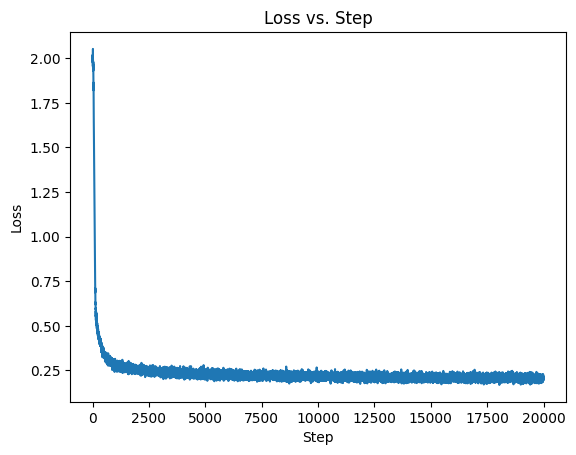

In [94]:
#################
# Training code #
#################

# Initialize probability path
path = GaussianConditionalProbabilityPath(
    p_data = MNISTSampler(),
    p_simple_shape = [1, 32, 32],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size = 32,
    patch_size = 4,
    num_layers = 8,
    c = 1,
    dim = 256,
    heads = 8,
    final_dim = 10,
    n_classes = 11,
).to(device)

# Initialize trainer
trainer = MNISTCFGTrainer(path = path, eta=0.35, null_label=10)

# Train! You should have reasonable results in ~15 A100 minutes
losses, steps = trainer.train(model=dit, num_steps = 20000, lr=0.4e-3, batch_size=256, ckpt_every=1000)

plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss vs. Step")
plt.show()

Let's view the output of our final model!

100%|██████████| 99/99 [00:12<00:00,  7.74it/s]


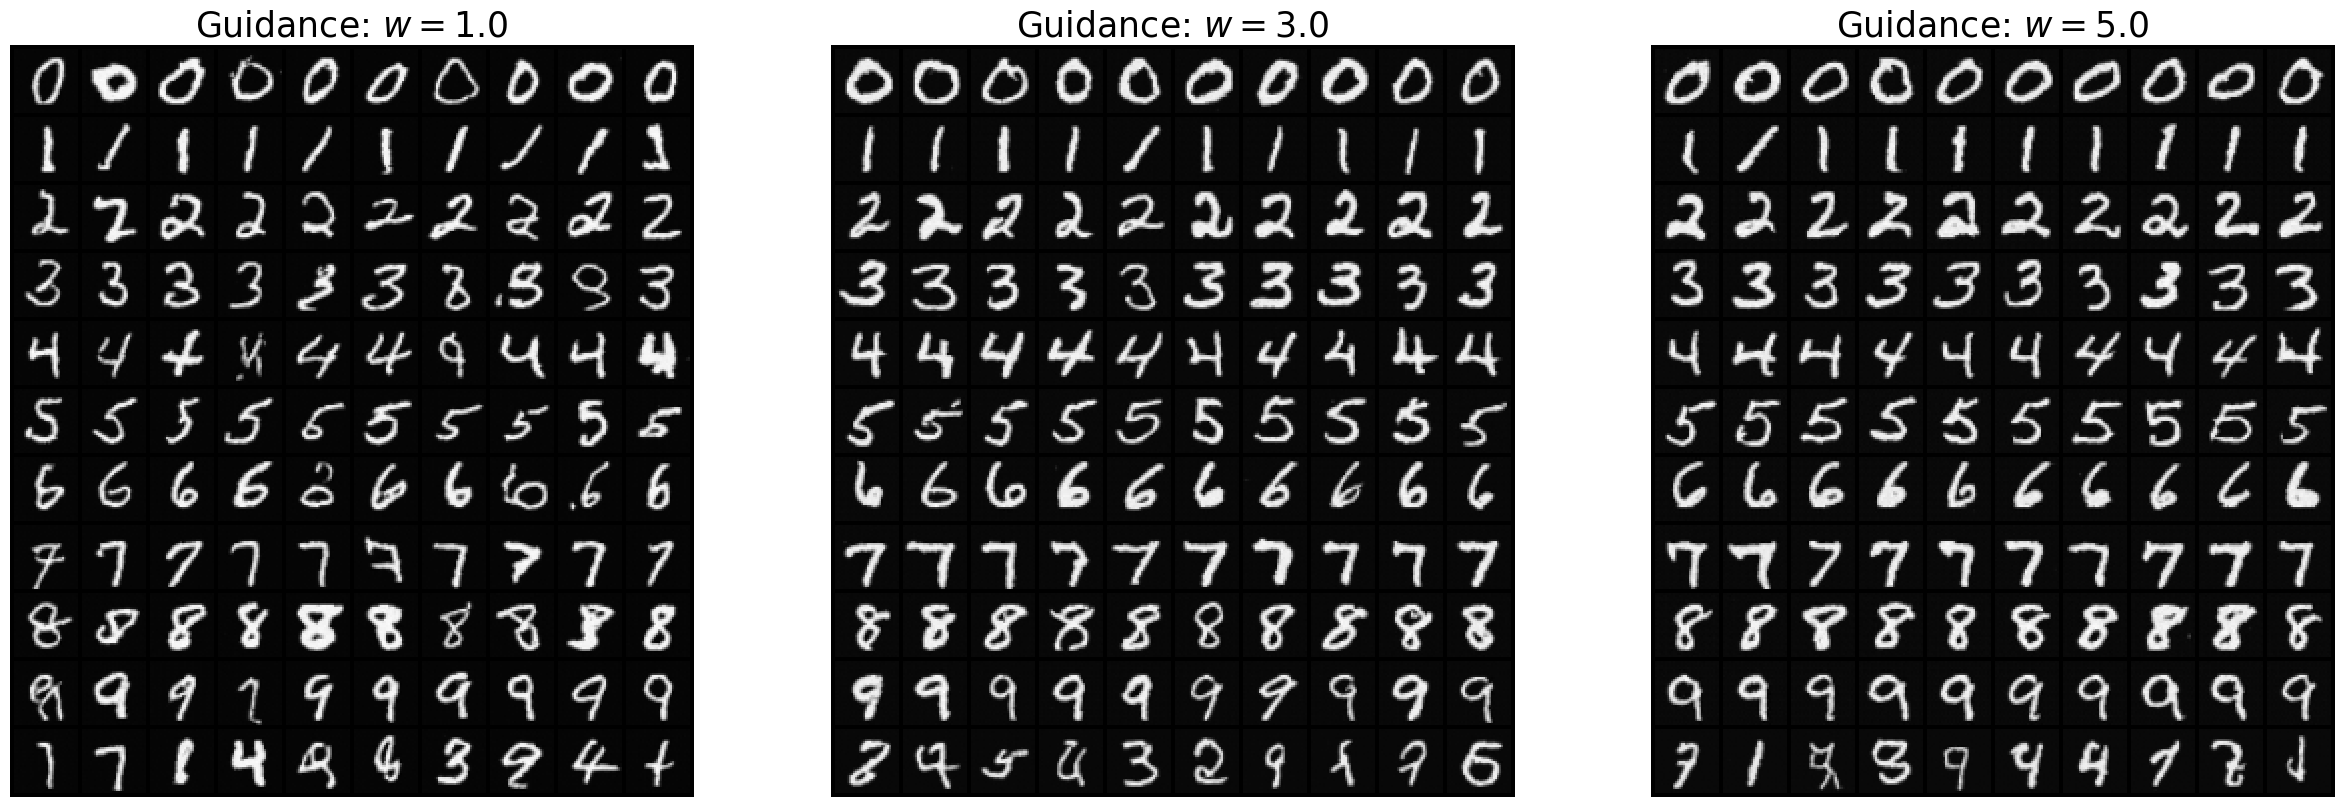

In [95]:
# Play with these!
samples_per_class = 10
num_timesteps = 100
guidance_scales = [1.0, 3.0, 5.0]

visualize_output(
    model=dit,
    path=path,
    samples_per_class=samples_per_class,
    num_timesteps=num_timesteps,
    guidance_scales=guidance_scales,
)
plt.show()

# Part 4: Training a Variational Autoencoder
In this section, we'll train a variational autoencoder (VAE) for MNIST. In the next section, we'll then train a diffusion transformer inside of the learned latent space. Recall from the notes that the overall structure of the VAE consists of

1. an *encoder* $q_\phi(z|x)$, mapping the input `x` with shape `b 1 32 32`, to outputs `z_mean` with shape `b c h w` and learned scalar `z_logvar`. Note that for training stability reasons, and in following the precedent of [2], we choose to indirectly parameterize the log-variance $\log \sigma_\phi(x)$.


2. a *decoder* $p_\theta(x|z)$ which similarly maps the latent `z` to outputs `x_mean` with shape `b 1 32 32` and learned scalar `x_logvar`.

Similar to the implementation of the diffusion transformer, we'll architect the encoder (resp. decoder) as a series of **blocks**, each of which contains several residual connections, followed by an attention layer, followed by a downsampling (resp. upsampling) layer with the exception of the final block. We'll now proceed component-by-component, providing a plain-English description of the component, and then asking you to fill in the details.

### Question 4.1: Residual Block
**Your job:** Implement the **ResidualBlock** class so as to realize the following recipe:

0. Save the input as `x_skip` to be added back at the end.
1. Apply some sort of layer normalization. We recommend `nn.GroupNorm(...)`. With `num_groups = 1`, this effectively becomes `nn.LayerNorm` across the flattened image.
2. Apply a convolutional layer with kernel size three.   
   (kernel_size - 1) / 2 = 1 每边减少1个像素，需要padding补一圈0  
3. Apply your favorite non-linear activation.
4. Apply a final, 1x1 convolution (with kernel size one).
5. Finally, realize the residual connection by returning the output of the previous step and `x_skip`.

In [96]:
class ResidualBlock(nn.Module):
  """ Two applications of LN + convolution + non-linearity + residual connection """
  def __init__(self, channels: int, act: nn.Module = nn.SiLU):
    super().__init__()

    # Init norm, convolutions, and activations
    self.norm = nn.GroupNorm(num_groups=1, num_channels=channels)
    self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1)
    self.act = act()
    self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=1)

    # Initialize the second convolution to zero - stabilizes training early on!
    nn.init.zeros_(self.conv2.weight)
    nn.init.zeros_(self.conv2.bias)

  def forward(self, x: torch.Tensor):
    # Res init
    x_skip = x # to be added back at the end

    # Norm
    x = self.norm(x)

    # First convolution
    x = self.conv1(x)

    # Activation
    x = self.act(x)

    # Second convolution
    x = self.conv2(x)

    # Return residual connection
    return x_skip + x

### Question 4.2: Attention Block
**Your job:** Implement the **AttnBlock** class so as to realize the following recipe:

0. Reshape from the image shape `b c h w` to the list-of-tokens shape `b (h w) c`. You may find `einops.rearrange` useful here.
2. Save `x_skip` for the next residual connection.
3. Apply normalization and multi-head attention (via the existing `MHA` class).
4. Residual connection using saved `x_skip`.
5. Save `x_skip` for the next residual connection.
6. Apply normalization and a feedforward layer.
7. Residual connection using saved `x_skip`.

In [97]:
class AttnBlock(nn.Module):
  def __init__(self, channels: int):
    super().__init__()

    # Reshape
    self.reshape1 = Rearrange('b c h w -> b (h w) c')

    # Norm + attention
    self.norm1 = nn.LayerNorm(channels, elementwise_affine=False)
    self.mha = MHA(channels, 4)

    # Norm + ff
    self.norm2 = nn.LayerNorm(channels, elementwise_affine=False)
    self.ff = MLP([channels, 4 * channels, channels])

  def forward(self, x: torch.Tensor):
    b, c, h, w = x.shape
    x = self.reshape1(x)

    x_skip = x
    # Attention + residual connection
    x = self.norm1(x)
    x = self.mha(x)
    x = x_skip + x

    x_skip = x
    # Feedforward + residual connection
    x = self.norm2(x)
    x = self.ff(x)
    x = x_skip + x
    
    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

### Question 4.3: Encoder Block
**Your job:** Implement the **EncoderBlock** class so as to realize the following recipe:

0. Apply two residual blocks.
1. Apply an attention block.
2. If downsample channels is not None, apply a downsampling convolution (a standard `nn.Conv2d` with `kernel_size=3`, `padding=1`, and `stride=2` will suffice).

In [98]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels: int, downsample_channels: Optional[int] = None):
    super().__init__()
    self.residual_blk1 = ResidualBlock(in_channels)
    self.residual_blk2 = ResidualBlock(in_channels)
    self.attention_blk = AttnBlock(in_channels)
    if downsample_channels:
      self.downsample_blk = nn.Conv2d(in_channels, downsample_channels, kernel_size=3, padding=1, stride=2)
    else:
      self.downsample_blk = None
      
  def forward(self, x: torch.Tensor):
    x = self.residual_blk1(x)
    x = self.residual_blk2(x)
    x = self.attention_blk(x)
    if self.downsample_blk:
      x = self.downsample_blk(x)
    return x

### Question 4.4: Encoder
**Your job:** Implement the **Encoder** class so as to realize the following recipe:

0. Apply an initial convolution from the number of input channels (one for MNIST) to the initial number of hidden channels.
1. Apply one encoder block for every hidden channel, downsampling for all but the last block.
2. Apply a final normalization + output 1x1 convolution layer to predict `z_mean`.
3. With `self.logvar = nn.Parameter(torch.zeros(()))`, return both `z_mean` and `self.logvar`.

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initial conv2d
    self.init_conv = nn.Conv2d(in_channels = in_channels, out_channels = hidden_channels[0], kernel_size=3, padding=1, stride=1)

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for in_c, out_c in zip(ch_in, ch_out):
      blocks.append(EncoderBlock(in_c, out_c))
    self.blocks = nn.ModuleList(blocks)

    # Predict z_mean
    z_dim = hidden_channels[-1]
    self.z_mean = nn.Sequential(
      nn.GroupNorm(1, z_dim),
      nn.Conv2d(in_channels = z_dim, out_channels = z_dim, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    # Map pixel values into a higher-dimensional feature space 
    # at the same spatial resolution with richer info.
    x = self.init_conv(x)
    
    # Extract features at each layer's resolution. Each block extracts features then downsamples: 
    # trading spatial (redundant details) resolution for richer channel representations and semantic/abstract info
    for each_blk in self.blocks: 
      x = each_blk(x)
    # Network would choose features as pattern to learn with linear projection.
    return self.z_mean(x), self.logvar(x)


### Question 4.5: Decoder Block
**Your job:** Implement the **DecoderBlock** class so as to realize the following recipe:

0. Apply two residual blocks.
1. Apply an attention block.
2. If upsample channels is not None, apply an upsampling consisting of e.g., `nn.Upsample` followed by a standard convolution.

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels: int, upsample_channels: Optional[int] = None):
    super().__init__()
    self.res1 = ResidualBlock(in_channels)
    self.res2 = ResidualBlock(in_channels)
    self.attn = AttnBlock(in_channels)
    if upsample_channels is not None:
      self.upsample = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_channels=in_channels, out_channels=upsample_channels, kernel_size=3, padding=1, stride=1),
      )
    else:
      self.upsample = None

  def forward(self, x: torch.Tensor):
    raise NotImplementedError("Fill me in!")

### Question 4.6: Decoder
**Your job:** Implement the **Decoder** class so as to realize the following recipe:

0. Apply one decoder block for every hidden channel, upsampling for all but the last block.
1. Apply a final normalization + output 1x1 convolution layer to predict `x_mean`.
2. With `self.logvar = nn.Parameter(torch.zeros(()))`, return both `x_mean` and `self.logvar`.

In [ ]:
class Decoder(nn.Module):
  def __init__(self, out_channels: int, hidden_channels: list[int]):
    super().__init__()

    # Initialize channels
    ch_in = hidden_channels
    ch_out = hidden_channels[1:] + [None]
    blocks = []
    for in_c, out_c in zip(ch_in, ch_out):
      blocks.append(DecoderBlock(in_c, out_c))
    self.blocks = nn.ModuleList(blocks)

    # Predict mean
    x_dim = hidden_channels[-1]
    self.x_mean = nn.Sequential(
      nn.GroupNorm(1, x_dim),
      nn.Conv2d(in_channels = x_dim, out_channels = out_channels, kernel_size=1, stride=1, padding=0),
    )

    # Scalar log-variance
    self.logvar = nn.Parameter(torch.zeros(()))

  def forward(self, x: torch.Tensor):
    raise NotImplementedError("Fill me in!")

### Question 4.7: Putting It Together
Finally, we assemble the sub-components above to complete the `VAE` class.

**Your job:** Implement `VAE.compute_loss(...)` to implement $L_{\text{VAE}}(\phi, \theta)$ from the main text (display (85)).

In [ ]:
class VAE(nn.Module):
  def __init__(self, data_channels: int, hidden_channels: list[int], beta: float = 0.1):
    super().__init__()
    self.beta = beta

    # Encoder
    self._encoder = Encoder(data_channels, hidden_channels)

    # Decoder
    self._decoder = Decoder(data_channels, list(reversed(hidden_channels)))

  def encode(self, x: torch.Tensor):
    return self._encoder(x)

  def decode(self, z: torch.Tensor):
    return self._decoder(z)

  def forward(self, x: torch.Tensor):
    z_mean, z_logvar = self.encode(x)
    z = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)
    x_mean, x_logvar = self.decode(z)
    return z_mean, z_logvar, x_mean, x_logvar

  def compute_loss(self, z_mean: torch.Tensor, z_logvar: torch.Tensor, x_mean: torch.Tensor, x_logvar: torch.Tensor, x_true: torch.Tensor):
    """ See display 85 from the text """
    # KL loss
    raise NotImplementedError("Fill me in!")

    # Reconstruction loss
    raise NotImplementedError("Fill me in!")

    return kl_loss + recon_loss

Before we train, we create a new `Trainer` subclass with which to train the VAE, and a helper function to visualize interpolation in the learned latent space.

In [ ]:
class MNISTVAETrainer(Trainer):
  def __init__(self, mnist_sampleable: LabeledSampleable, batch_size: int = 64, **kwargs):
    super().__init__(**kwargs)
    self.mnist = mnist_sampleable
    self.batch_size = batch_size

  def get_train_loss(self):
    """ See display 85 from the text """
    x, y = self.mnist.sample(self.batch_size)
    z_mean, z_std, x_mean, x_std = self.model(x)
    return self.model.compute_loss(z_mean, z_std, x_mean, x_std, x)

  @torch.no_grad()
  def checkpoint(self, step: int):
    # Save model
    torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_model.pt'))
    torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:06d}_opt.pt'))

    # Save output visualization, using x_mean as reconstruction
    b = 10
    x, _ = self.mnist.sample(b)
    _, _, x_mean, _ = self.model(x)
    x_all = torch.cat([x, x_mean], dim=0)
    grid = make_grid(x_all, nrow=b, normalize=True, value_range=(0,1))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    plt.axis("off")
    plt.title("VAE Reconstruction")
    plt.savefig(os.path.join(self.output_dir, f'step_{step:06d}_output.png'))
    plt.close()

@torch.no_grad()
def visualize_latent_interpolation(x1: torch.Tensor, x2: torch.Tensor, vae: VAE, n_steps: int, save_path: Optional[str] = None):
   z1_mean, z1_logvar = vae.encode(x1)
   z1 = z1_mean + torch.exp(0.5 * z1_logvar) * torch.randn_like(z1_mean) # 1 c h w

   z2_mean, z2_logvar = vae.encode(x2)
   z2 = z2_mean + torch.exp(0.5 * z2_logvar) * torch.randn_like(z2_mean) # 1 c h w

   lambdas = torch.linspace(0, 1, n_steps).to(z1.device)
   zs = (1 - lambdas) * z1.unsqueeze(-1) + lambdas * z2.unsqueeze(-1) # 1 c h w n_steps
   zs = rearrange(zs, '1 c h w n -> n c h w')
   samples, _ = vae.decode(zs) # n_steps 1 h w

   grid = make_grid(samples, nrow=n_steps, normalize=True, value_range=(0, 1))
   plt.figure(figsize=(n_steps * 2, 2))
   plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
   plt.axis("off")
   plt.title("Latent Interpolation")
   if save_path is not None:
       plt.savefig(save_path)
       plt.close()
   else:
       plt.show()
   return samples

Finally, let's train the VAE.

In [ ]:
# Create dataset + VAE
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")  

mnist = MNISTSampler().to(device)
vae = VAE(
   data_channels = 1,
   hidden_channels = [16, 32, 64, 128],
   beta = 10.0,
).to(device)

# Create Trainer + train
trainer = MNISTVAETrainer(
    mnist_sampleable = mnist,
    batch_size = 64,
)
losses, steps = trainer.train(
   model = vae,
   num_steps = 5000,
   lr = 1e-3,
   warmup_steps = 500,
   ckpt_every = 250,
)
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Perform interpolation in the latent space
vae.eval()
samples, _ = mnist.sample(2)
interpolated_samples = visualize_latent_interpolation(
   x1 = samples[:1],
   x2 = samples[1:2],
   vae = vae,
   n_steps = 10,
) # n_steps 1 h w

# Part 5: Training a Latent Diffusion Model
In this section, we'll train a diffusion transformer inside of the latent space of a trained VAE. Fortunately for us, most of the work has already been done! It remains now to simply put all of the pieces - VAE, latent probability path, and diffusion transformer - together.

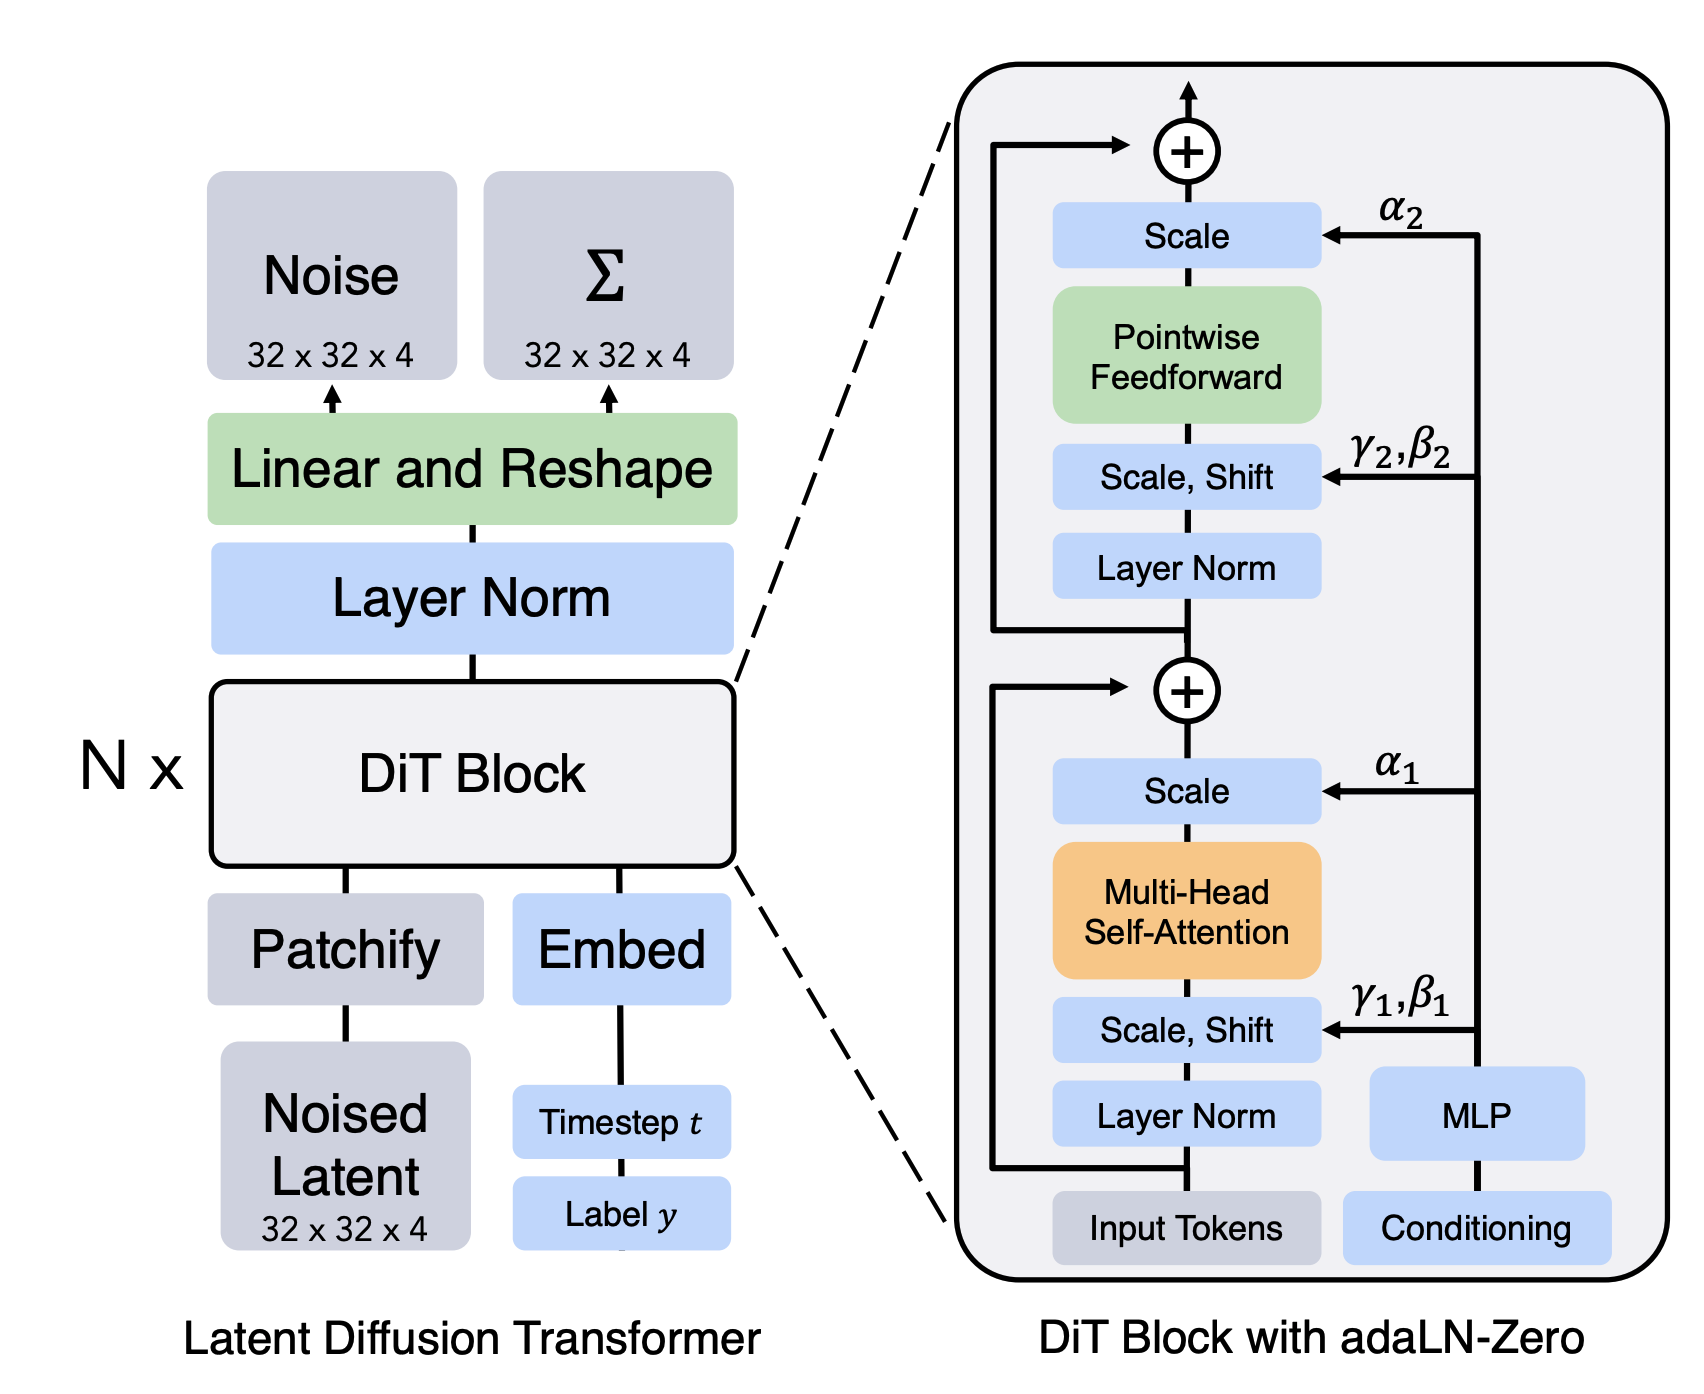

### Question 5.1: Latent Diffusion Trainer
Below is a partial implementation of `LatentCFGTrainer` an extension of `CFGTrainer` for training in the latent space of a VAE.

**Your job:** Implement `LatentCFGTrainer.get_train_loss`.

**Hint:**
1. Adapt `CFGTrainer.get_train_loss`, but instead of calling `self.path.p_data.sample(...)`, you'll need to sample directly from MNIST, and then pass through the encoder.
2. Make sure to guard the call to `vae.encode` under `torch.no_grad()`!

In [ ]:
class LatentCFGTrainer(Trainer):
    def __init__(
        self,
        mnist: MNISTSampler,
        vae: VAE,
        path: GaussianConditionalProbabilityPath,
        eta: float,
        null_label: int,
        eps: float = 0.001,
        **kwargs
    ):
        assert eta > 0 and eta < 1
        super().__init__(**kwargs)
        self.mnist = mnist
        self.vae = vae
        self.path = path
        self.eta = eta
        self.eps = eps
        self.path = path
        self.null_label = null_label

    @torch.no_grad()
    def visualize_samples(self, save_path: str, samples_per_class: int = 10, num_timesteps: int = 100, guidance_scales: List[float] = [1.0, 3.0, 5.0], use_tqdm = False):
      # Graph
      fig, axes = plt.subplots(1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10))

      for idx, w in enumerate(guidance_scales):
          # Setup ode and simulator
          ode = CFGVectorFieldODE(self.model, guidance_scale=w, null_label=10)
          simulator = EulerSimulator(ode)

          # Sample initial conditions
          y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
          num_samples = y.shape[0]
          z0 = self.path.p_simple.sample(num_samples)

          # Simulate
          ts = torch.linspace(0,0.999,num_timesteps).view(1, -1, 1, 1, 1).expand(num_samples, -1, 1, 1, 1).to(device)
          z1 = simulator.simulate(z0, ts, y=y, use_tqdm=use_tqdm)

          # Decode
          x1, _ = self.vae.decode(z1)

          # Plot
          v_min, v_max = x1.min(), x1.max()
          x1 = (x1 - v_min) / (v_max - v_min)
          grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(0,1))
          axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
          axes[idx].axis("off")
          axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)

      # Save
      if save_path is not None:
          plt.savefig(save_path)
          plt.close()
      else:
        plt.show()

    plt.show()

    def checkpoint(self, step: int):
      # Save model
      torch.save(self.model.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_model.pt'))
      torch.save(self.opt.state_dict(), os.path.join(self.output_dir, f'step_{step:6d}_opt.pt'))

      # Save output visualization
      self.visualize_samples(save_path=os.path.join(self.output_dir, f'step_{step:6d}_output.png'))

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z, y from MNIST + encode
        with torch.no_grad():
          raise NotImplementedError("Fill me in!")


        # Step 2: Set each label to 10 (i.e., null) with probability eta
        raise NotImplementedError("Fill me in!")


        # Step 3: Sample t and x
        raise NotImplementedError("Fill me in!")


        # Step 4: Regress and output loss
        raise NotImplementedError("Fill me in!")


In [ ]:
# Finally, let's train!

vae = vae.to(device) # VAE(data_channels = 1, hidden_channels = [16, 32, 64, 128], beta = 1.0)

# Initialize latent probability path
c = 128
img_size = 4

path = GaussianConditionalProbabilityPath(
    p_data = None,
    p_simple_shape = [c, img_size, img_size],
    alpha = LinearAlpha(),
    beta = LinearBeta()
).to(device)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size = img_size,
    patch_size = 1,
    num_layers = 8,
    c = c,
    dim = 256,
    heads = 8,
    final_dim = 10,
    n_classes = 11,
).to(device)

# Dataset
mnist = MNISTSampler().to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    mnist = mnist,
    vae = vae,
    path = path,
    eta=0.35,
    null_label=10
)

# Train! You should have reasonable results in ~15 A100 minutes
losses, steps = trainer.train(model=dit, num_steps = 10000, lr=0.4e-3, batch_size=256, ckpt_every=500)

plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss vs. Step")
plt.show()

### References:
1. William Peebles and Saining Xie. Scalable Diffusion Models with Transformers. 2023. arXiv: 2212 . 09748
[cs.CV]. url: https://arxiv.org/abs/2212.09748.
2. Robin Rombach et al. High-Resolution Image Synthesis with Latent Diffusion Models. 2022. arXiv: 2112.10752
[cs.CV]. url: https://arxiv.org/abs/2112.10752.
